In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
df = pd.read_excel('../data/Tableau BlinkIT Grocery Project U16955293080 (4) (2).xlsx')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (8523, 12)

First 5 rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df.info()
print("\nNull values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB

Null values per column:
Item_Identifier                 0
I

In [7]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [8]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})
print("Fat Content values after fix:")
print(df['Item_Fat_Content'].value_counts())

Fat Content values after fix:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [9]:
df['Item_Weight'] = df.groupby('Item_Type')['Item_Weight'].transform(
    lambda x: x.fillna(x.median())
)
print("Missing Item_Weight after fill:", df['Item_Weight'].isnull().sum())

Missing Item_Weight after fill: 0


In [10]:
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Small'
)
df['Outlet_Size'] = df.apply(
    lambda row: outlet_size_mode[row['Outlet_Type']] 
    if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)
print("Missing Outlet_Size after fill:", df['Outlet_Size'].isnull().sum())

Missing Outlet_Size after fill: 0


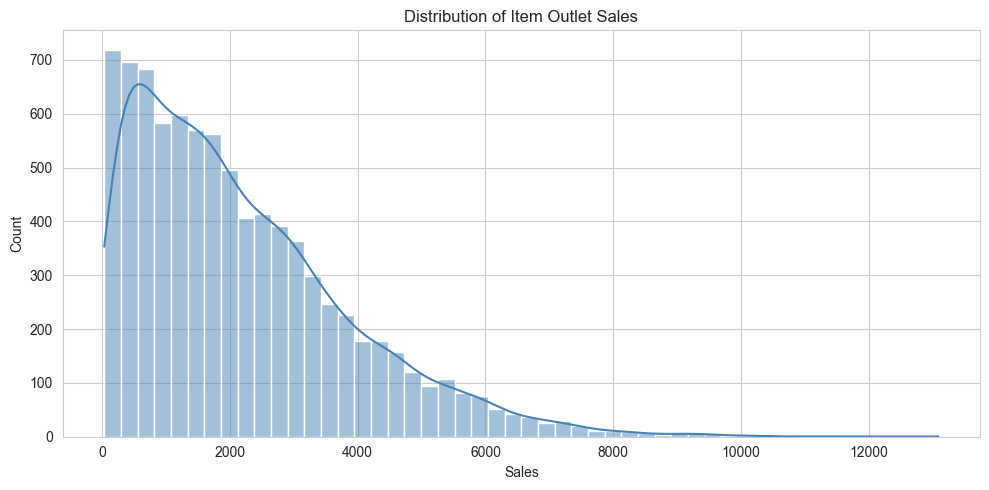

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Item_Outlet_Sales'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/sales_distribution.png', dpi=150)
plt.show()

/var/folders/cc/75b1ky1508z3814t00pdgrh00000gp/T/ipykernel_3431/1523786161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', palette='Set2')


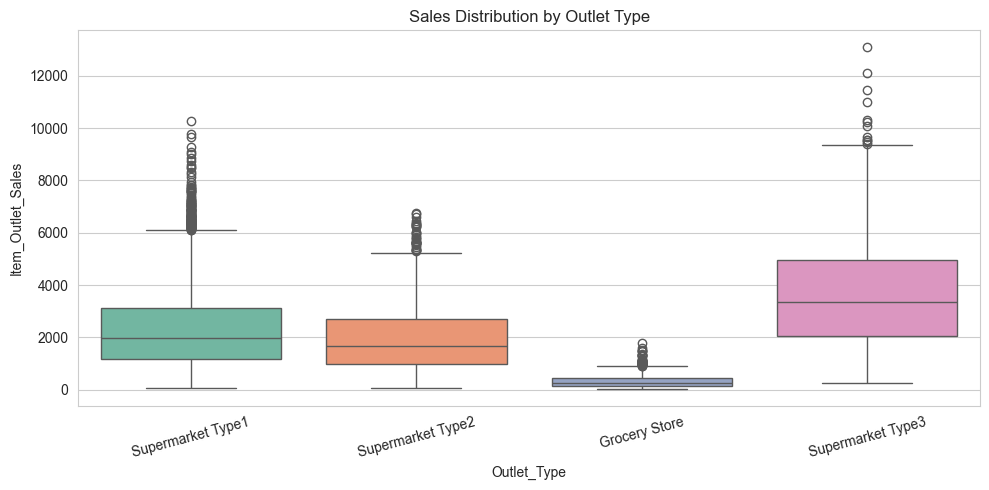

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales', palette='Set2')
plt.title('Sales Distribution by Outlet Type')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/sales_by_outlet_type.png', dpi=150)
plt.show()

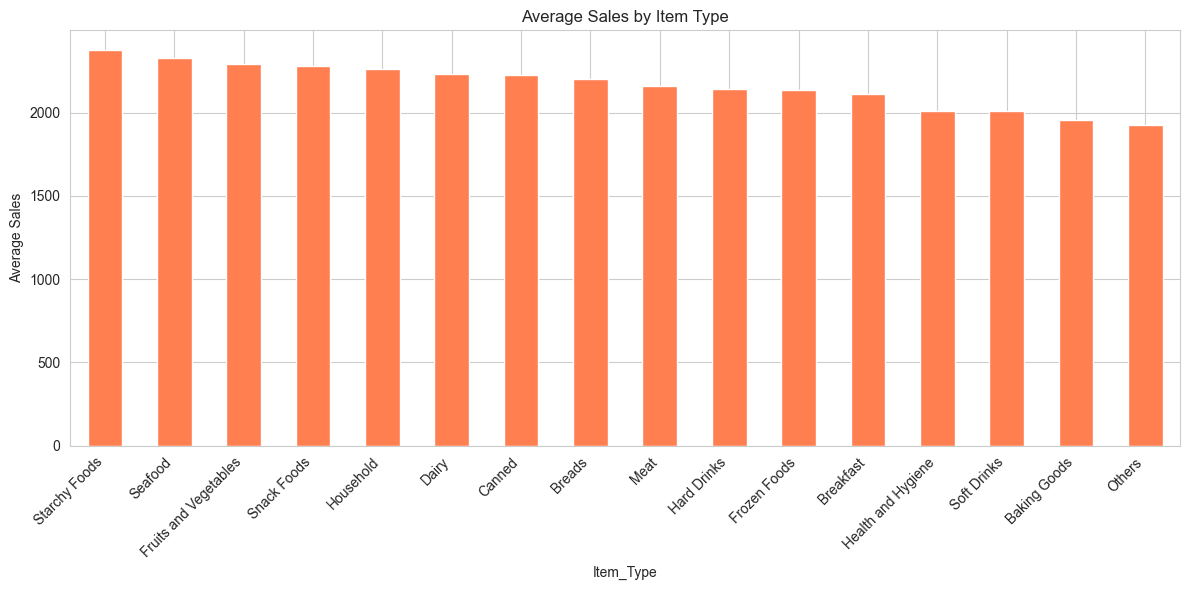

In [13]:
item_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
item_sales.plot(kind='bar', color='coral')
plt.title('Average Sales by Item Type')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/sales_by_item_type.png', dpi=150)
plt.show()

In [14]:
df.to_csv('../outputs/cleaned_data.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
